***Importing Libraries:***

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

***Data Loading and Preprocessing:***

In [2]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")
data_dir = path
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'test')

Using Colab cache for faster access to the 'fer2013' dataset.


In [3]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
validation_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode='grayscale'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


***EDA: (Visualizing Some Images)***

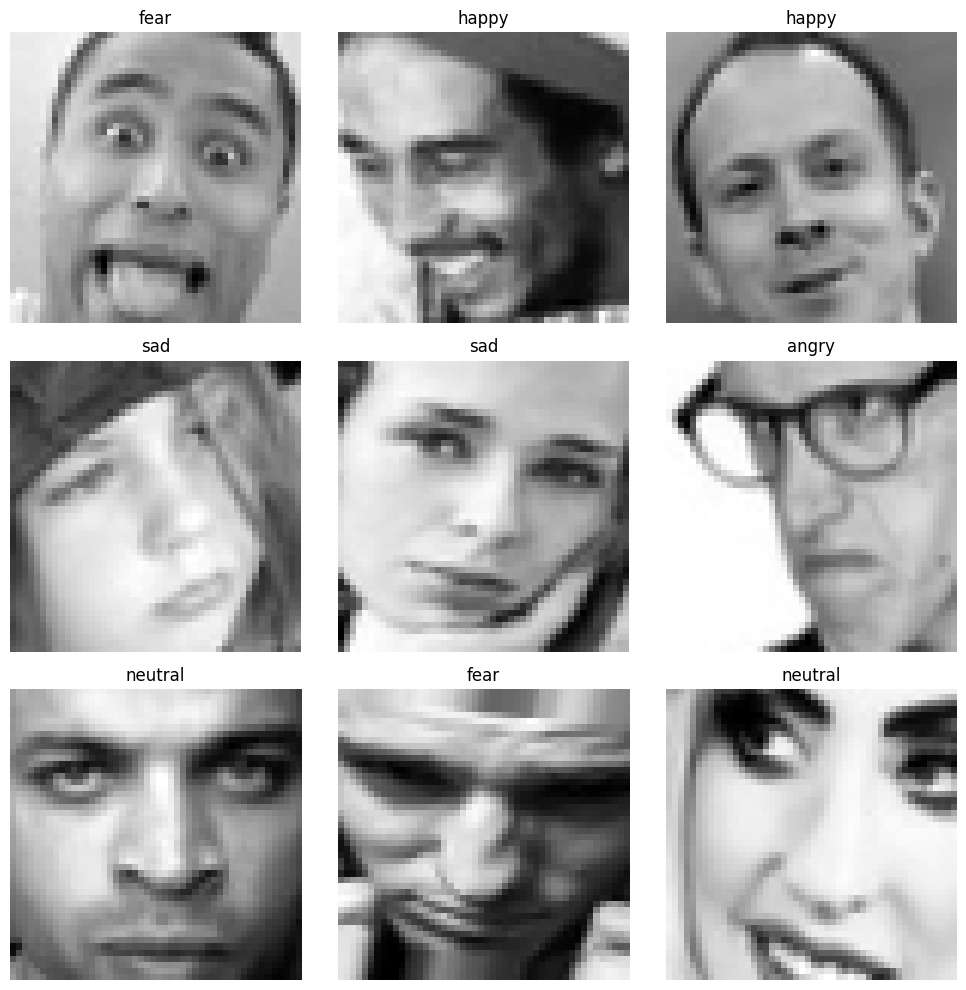

In [4]:
class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].reshape(48, 48), cmap='gray')
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

***CNN Model Architecture:***

In [5]:
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,474,759 (9.44 MB)

 Trainable params: 2,472,839 (9.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

***Model Training:***

In [6]:
history= model.fit(train_generator, validation_data=validation_generator, epochs=100)

Epoch 1/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 423ms/step - accuracy: 0.2778 - loss: 2.1009 - val_accuracy: 0.3149 - val_loss: 1.8970
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.3803 - loss: 1.6165 - val_accuracy: 0.3509 - val_loss: 1.7537
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.4429 - loss: 1.4589 - val_accuracy: 0.4894 - val_loss: 1.3339
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.4648 - loss: 1.3969 - val_accuracy: 0.5015 - val_loss: 1.3058
Epoch 5/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.4846 - loss: 1.3595 - val_accuracy: 0.5063 - val_loss: 1.3074
Epoch 6/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - accuracy: 0.4929 - loss: 1.3252 - val_accuracy: 0.5045 - val_loss: 1.3214
Epoch 7/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.5039 - loss: 1.2955 - val_accuracy: 0.5084 - val_loss: 1.3219
Epoch 8/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.5179 - loss:

***Detection System:***

In [7]:
history = model.history.history
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step


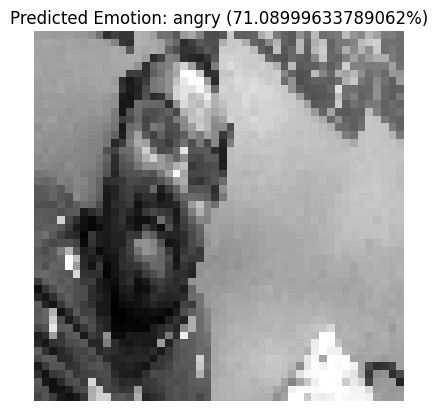

Emotion: angry, Confidence: 71.08999633789062%


In [11]:
predicted_emotion, confidence = detect_emotion(r'/test.jpg')
print(f"Emotion: {predicted_emotion}, Confidence: {confidence}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


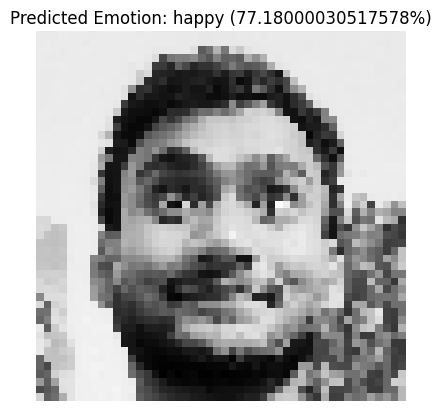

Emotion: happy, Confidence: 77.18000030517578%


In [13]:
predicted_emotion, confidence = detect_emotion(r'/test2.jpg')
print(f"Emotion: {predicted_emotion}, Confidence: {confidence}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


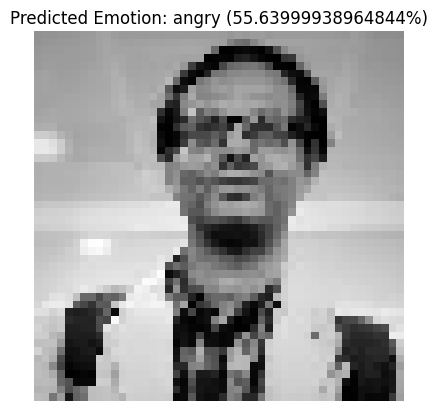

Emotion: angry, Confidence: 55.63999938964844%


In [14]:
predicted_emotion, confidence = detect_emotion(r'/test3.jpg')
print(f"Emotion: {predicted_emotion}, Confidence: {confidence}%")

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def detect_emotion(image_path):
    img = image.load_img(image_path, target_size=(48, 48), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = round(prediction[0][predicted_index] * 100, 2)  # Confidence in %

    # Display the image with the predicted label and confidence
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted Emotion: {predicted_class} ({confidence}%)')
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

***Evaluation Matrics:***

***Accuracy & Loss:***

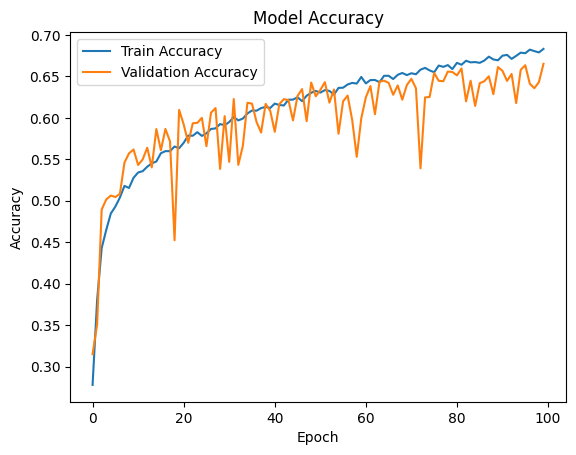

In [15]:
# # Accuracy
# #plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')

# plt.legend()
import matplotlib.pyplot as plt

plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


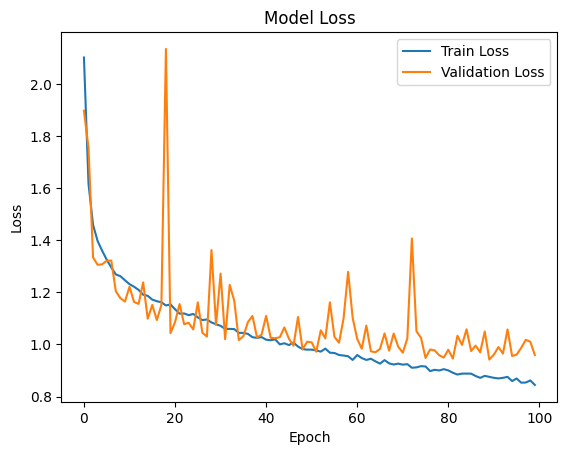

In [16]:
# Loss
#plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [17]:
# Assuming you're using a Keras model and a generator like validation_generator

# Get predictions
y_pred_prob = model.predict(validation_generator)
y_pred = y_pred_prob.argmax(axis=1)  # convert from probabilities to class indices

# Get true labels from the generator
y_true = validation_generator.classes


113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step


***Classification Report:***

In [24]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print('Classification Report')
# Pull a batch of validation data
val_images, val_labels = next(validation_generator)

# Get model predictions
preds = model.predict(val_images)

# Convert one-hot labels to indices
y_true = np.argmax(val_labels, axis=1)
y_pred = np.argmax(preds, axis=1)

# Fix: changed 'class_name' to 'class_names'
# Added the 'labels' parameter to explicitly define all class indices
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(len(class_names))))

Classification Report
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

       angry       0.64      0.75      0.69        12
     disgust       1.00      0.50      0.67         2
        fear       0.29      0.33      0.31         6
       happy       0.89      0.89      0.89        18
     neutral       0.30      0.60      0.40         5
         sad       0.50      0.23      0.32        13
    surprise       0.62      0.62      0.62         8

    accuracy                           0.61        64
   macro avg       0.61      0.56      0.56        64
weighted avg       0.63      0.61      0.60        64



***Confusion Matrix:***

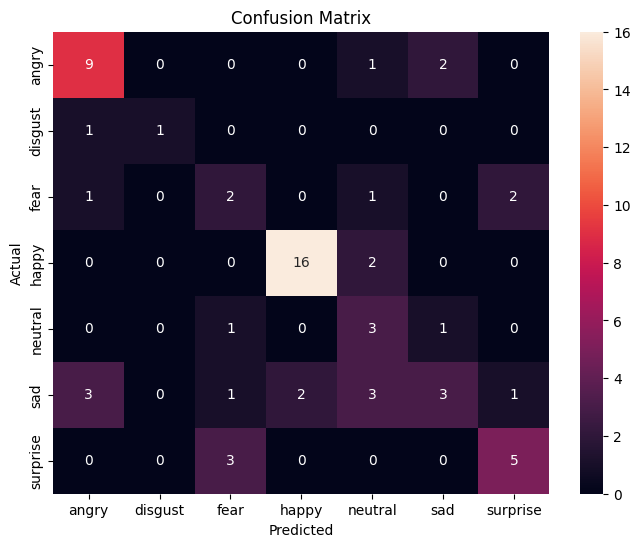

In [26]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

***Save the Model***

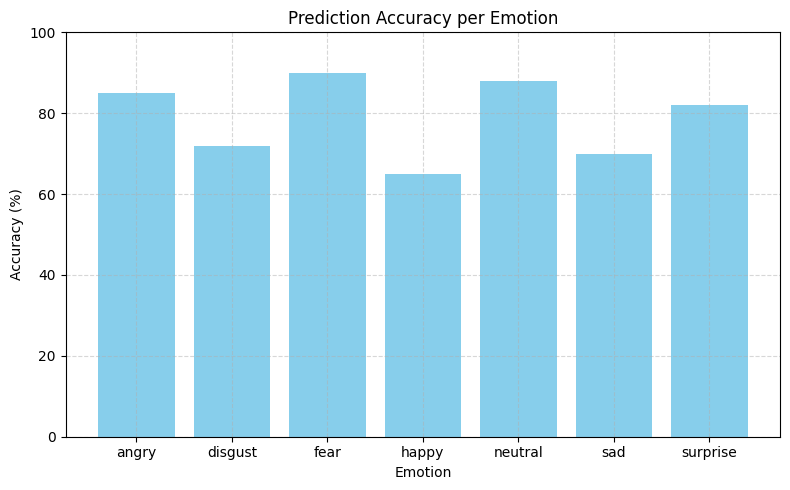

In [28]:
import matplotlib.pyplot as plt

emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
accuracies = [85, 72, 90, 65, 88, 70, 82]  # Example data

plt.figure(figsize=(8,5))
plt.bar(emotions, accuracies, color='skyblue')
plt.title('Prediction Accuracy per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
model.save('micro_expression.h5')